## 0. Setup, Load, and Clean

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Global plotting style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
p

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 2.2.3 | numpy 2.1.3 | seaborn 0.13.2


In [5]:
# --- Load ---------------------------------------------------------------
PATH = "food_delivery_orders.csv"      # same folder as this notebook
df = pd.read_csv(PATH, parse_dates=["order_date"])

print("Shape:", df.shape)
df.head()

Shape: (4200, 9)


,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2023-01-01,Karachi,Fine Dining,Continental,"2,768.000",25.000,36.200,4.500,95.000
1,2023-01-01,Karachi,Fine Dining,Steakhouse,"4,979.000",44.800,23.300,4.800,-437.000
2,2023-01-01,Karachi,Cloud Kitchen,Indian,"4,008.000",11.900,39.600,4.200,618.000
3,2023-01-01,Islamabad,Fine Dining,Steakhouse,"3,260.000",8.300,35.800,4.500,423.000
4,2023-01-01,Karachi,Fast Food,Pizza,435.000,13.500,29.400,4.800,53.000


In [6]:
# --- Structural check ---------------------------------------------------
print("--- dtypes ---")
print(df.dtypes, end="\n\n")

print("--- missing values per column ---")
print(df.isna().sum(), end="\n\n")

print("--- exact duplicate rows ---")
print(df.duplicated().sum(), end="\n\n")

print("--- date range ---")
print(df["order_date"].min().date(), "to", df["order_date"].max().date(), end="\n\n")

print("--- categorical levels ---")
for col in ["city", "restaurant_category", "cuisine"]:
    print(f"{col:22s} ({df[col].nunique()}): {sorted(df[col].unique())}")

--- dtypes ---
order_date             datetime64[ns]
city                           object
restaurant_category            object
cuisine                        object
order_value                   float64
discount_percent              float64
delivery_time_min             float64
rating                        float64
profit_per_order              float64
dtype: object

--- missing values per column ---
order_date             0
city                   0
restaurant_category    0
cuisine                0
order_value            0
discount_percent       0
delivery_time_min      0
rating                 0
profit_per_order       0
dtype: int64

--- exact duplicate rows ---
0

--- date range ---
2023-01-01 to 2024-06-30

--- categorical levels ---
city                   (5): ['Faisalabad', 'Islamabad', 'Karachi', 'Lahore', 'Multan']
restaurant_category    (5): ['Cafe', 'Cloud Kitchen', 'Dessert', 'Fast Food', 'Fine Dining']
cuisine                (18): ['Bakery', 'Biryani', 'Breakfast', 'Burger

In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_date,4200,2023-09-30 13:56:13.714285824,2023-01-01 00:00:00,2023-05-15 00:00:00,2023-09-28 00:00:00,2024-02-15 00:00:00,2024-06-30 00:00:00,NaN
order_value,"4,200.000","1,148.396",150.000,490.000,740.500,"1,259.250","15,943.034","1,513.776"
discount_percent,"4,200.000",12.243,0.200,5.800,10.400,16.400,45.000,8.485
delivery_time_min,"4,200.000",34.542,10.000,26.800,32.500,38.400,132.700,14.594
rating,"4,200.000",4.509,2.400,4.300,4.500,4.800,5.000,0.387
profit_per_order,"4,200.000",57.370,"-5,994.458",22.000,80.000,159.000,"1,423.000",524.065


In [8]:
# --- Clean --------------------------------------------------------------
clean = df.copy()

clean["city"] = clean["city"].astype("category")


print("Extreme orders flagged:", clean["is_extreme_order"].sum(),
      f"({clean['is_extreme_order'].mean():.2%} of rows)")
print("Heavily discounted orders:", clean["heavy_discount"].sum())

clean.to_csv("food_delivery_orders_cleaned.csv", index=False)
print("\nSaved -> food_delivery_orders_cleaned.csv", clean.shape)
clean.head()

Extreme orders flagged: 70 (1.67% of rows)
Heavily discounted orders: 690

Saved -> food_delivery_orders_cleaned.csv (4200, 12)


,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order,heavy_discount,order_month,is_extreme_order
0,2023-01-01,Karachi,Fine Dining,Continental,"2,768.000",25.000,36.200,4.500,95.000,True,2023-01-01,False
1,2023-01-01,Karachi,Fine Dining,Steakhouse,"4,979.000",44.800,23.300,4.800,-437.000,True,2023-01-01,False
2,2023-01-01,Karachi,Cloud Kitchen,Indian,"4,008.000",11.900,39.600,4.200,618.000,False,2023-01-01,False
3,2023-01-01,Islamabad,Fine Dining,Steakhouse,"3,260.000",8.300,35.800,4.500,423.000,False,2023-01-01,False
4,2023-01-01,Karachi,Fast Food,Pizza,435.000,13.500,29.400,4.800,53.000,False,2023-01-01,False


In [9]:
NUMERIC_COLS = ["order_value", "discount_percent", "delivery_time_min",
                "rating", "profit_per_order"]

---
# Task 1 — Univariate, properly read

> Management wants to advertise a single number for "typical delivery time." Plot a histogram with KDE
> overlay of `delivery_time_min`, report its skewness, compare mean vs. median, and recommend which is
> the more honest number to advertise.

*Ladder position: **univariate** — one numeric column, so we care about centre, spread, and shape.*

In [10]:
dt = clean["delivery_time_min"]

skew_val = dt.skew()
mean_val, median_val, mode_val = dt.mean(), dt.median(), dt.mode()[0]

print(f"Skewness            : {skew_val:.3f}   (>0 right-skew, <0 left-skew, ~0 symmetric)")
print(f"Mean                : {mean_val:.2f} min")
print(f"Median              : {median_val:.2f} min")
print(f"Mode                : {mode_val:.2f} min")
print(f"Mean - Median       : {mean_val - median_val:.2f} min")
print(f"Std. deviation      : {dt.std():.2f} min")
print(f"Min / Max           : {dt.min():.1f} / {dt.max():.1f} min")
print(f"95th percentile     : {dt.quantile(0.95):.1f} min")
print(f"% of orders above the mean : {(dt > mean_val).mean():.1%}")

Skewness            : 2.877   (>0 right-skew, <0 left-skew, ~0 symmetric)
Mean                : 34.54 min
Median              : 32.50 min
Mode                : 30.00 min
Mean - Median       : 2.04 min
Std. deviation      : 14.59 min
Min / Max           : 10.0 / 132.7 min
95th percentile     : 51.3 min
% of orders above the mean : 40.2%


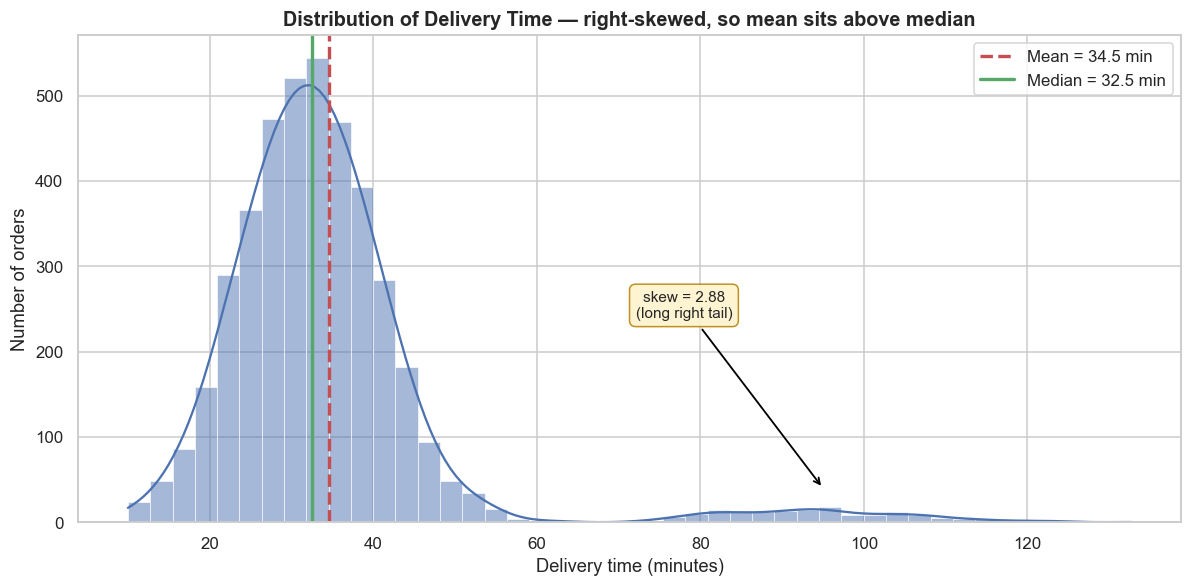

In [11]:
fig, ax = plt.subplots(figsize=(11, 5.5))

sns.histplot(dt, bins=45, kde=True, color="#4C72B0",
             edgecolor="white", linewidth=0.4, ax=ax)

ax.axvline(mean_val,   color="#C44E52", lw=2.2, ls="--",
           label=f"Mean = {mean_val:.1f} min")
ax.axvline(median_val, color="#55A868", lw=2.2, ls="-",
           label=f"Median = {median_val:.1f} min")

ax.set_title("Distribution of Delivery Time — right-skewed, so mean sits above median")
ax.set_xlabel("Delivery time (minutes)")
ax.set_ylabel("Number of orders")
ax.legend()

ax.annotate(f"skew = {skew_val:.2f}\n(long right tail)",
            xy=(95, 40), xytext=(78, 240),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
            fontsize=10, ha="center",
            bbox=dict(boxstyle="round,pad=0.4", fc="#FFF3CD", ec="#B8860B", alpha=0.9))

plt.tight_layout()
plt.show()

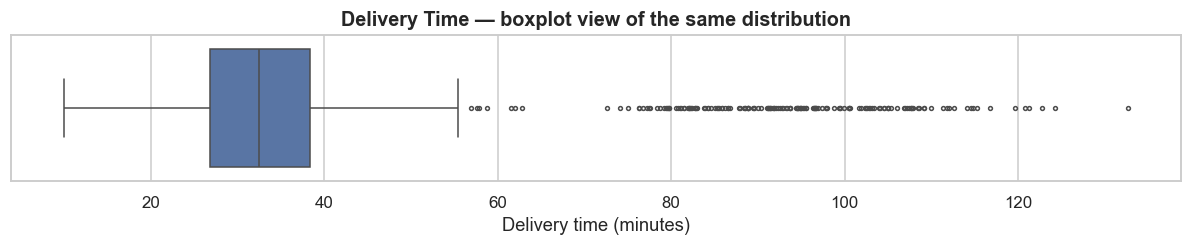

In [12]:
# Boxplot companion — makes the long right tail explicit
fig, ax = plt.subplots(figsize=(11, 2.4))
sns.boxplot(x=dt, color="#4C72B0", fliersize=2.5, ax=ax)
ax.set_title("Delivery Time — boxplot view of the same distribution")
ax.set_xlabel("Delivery time (minutes)")
plt.tight_layout()
plt.show()

---
# Task 2 — Categorical × numerical, beyond the average

> For `rating` by `city`, build a violin plot and a jittered strip plot of the same data. Which city shows
> the most **inconsistent** customer experience — a wide spread or a bimodal pattern — rather than just a
> low average rating?

*Ladder position: **bivariate** — one categorical against one numeric. A bar of means would answer
"what's typical per city" and hide the spread entirely, which is precisely the question being asked.*

In [13]:
city_stats = (clean.groupby("city", observed=True)["rating"]
                   .agg(n="count", mean="mean", median="median",
                        std="std", skew="skew",
                        p05=lambda s: s.quantile(0.05),
                        p95=lambda s: s.quantile(0.95),
                        iqr=lambda s: s.quantile(0.75) - s.quantile(0.25),
                        pct_below_4=lambda s: (s < 4).mean() * 100)
                   .sort_values("std", ascending=False))

print("Rating dispersion by city (sorted by standard deviation)\n")
display(city_stats.round(3))

print(f"\nSpread of the CITY MEANS: {city_stats['mean'].max() - city_stats['mean'].min():.3f} rating points")
print(f"Spread WITHIN a typical city (std): ~{city_stats['std'].mean():.3f} rating points")

Rating dispersion by city (sorted by standard deviation)



,n,mean,median,std,skew,p05,p95,iqr,pct_below_4
city,,,,,,,,,
Multan,386,4.521,4.600,0.401,-1.207,3.800,5.000,0.500,8.031
Lahore,1324,4.511,4.500,0.397,-1.014,3.815,5.000,0.500,7.628
Faisalabad,492,4.490,4.500,0.384,-0.774,3.900,5.000,0.525,8.740
Karachi,1163,4.508,4.500,0.380,-0.906,3.900,5.000,0.500,7.309
Islamabad,835,4.512,4.500,0.374,-0.805,3.900,5.000,0.500,7.186



Spread of the CITY MEANS: 0.031 rating points
Spread WITHIN a typical city (std): ~0.387 rating points


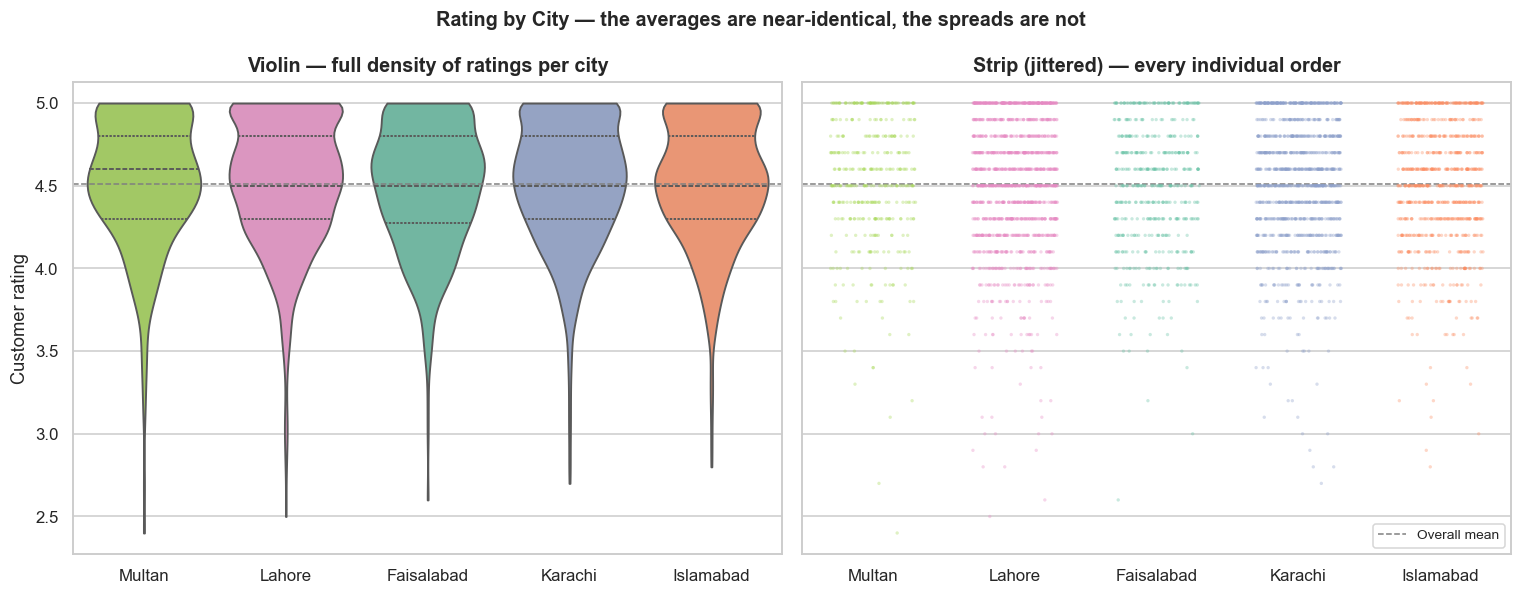

In [14]:
order = list(city_stats.index)   # widest spread first

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

sns.violinplot(data=clean, x="city", y="rating", order=order,
               hue="city", legend=False, inner="quartile",
               cut=0, palette="Set2", ax=axes[0])
axes[0].set_title("Violin — full density of ratings per city")
axes[0].set_xlabel("")
axes[0].set_ylabel("Customer rating")

sns.stripplot(data=clean, x="city", y="rating", order=order,
              hue="city", legend=False, jitter=0.30,
              size=2.2, alpha=0.35, palette="Set2", ax=axes[1])
axes[1].set_title("Strip (jittered) — every individual order")
axes[1].set_xlabel("")

for ax in axes:
    ax.axhline(clean["rating"].mean(), color="grey", ls="--", lw=1,
               label="Overall mean")
axes[1].legend(loc="lower right", fontsize=9)



---
# Task 3 — Multivariate encoding

> Build a single scatter plot of `delivery_time_min` vs. `rating` encoding a 3rd variable via **hue**
> (`city`) and a 4th via **size** (`order_value`). State one pattern — about whether high-value orders get
> faster or better-rated delivery — that is only visible because of the 4-variable encoding.

*Ladder position: **multivariate** — four variables in one frame, using position × 2, colour, and size.*

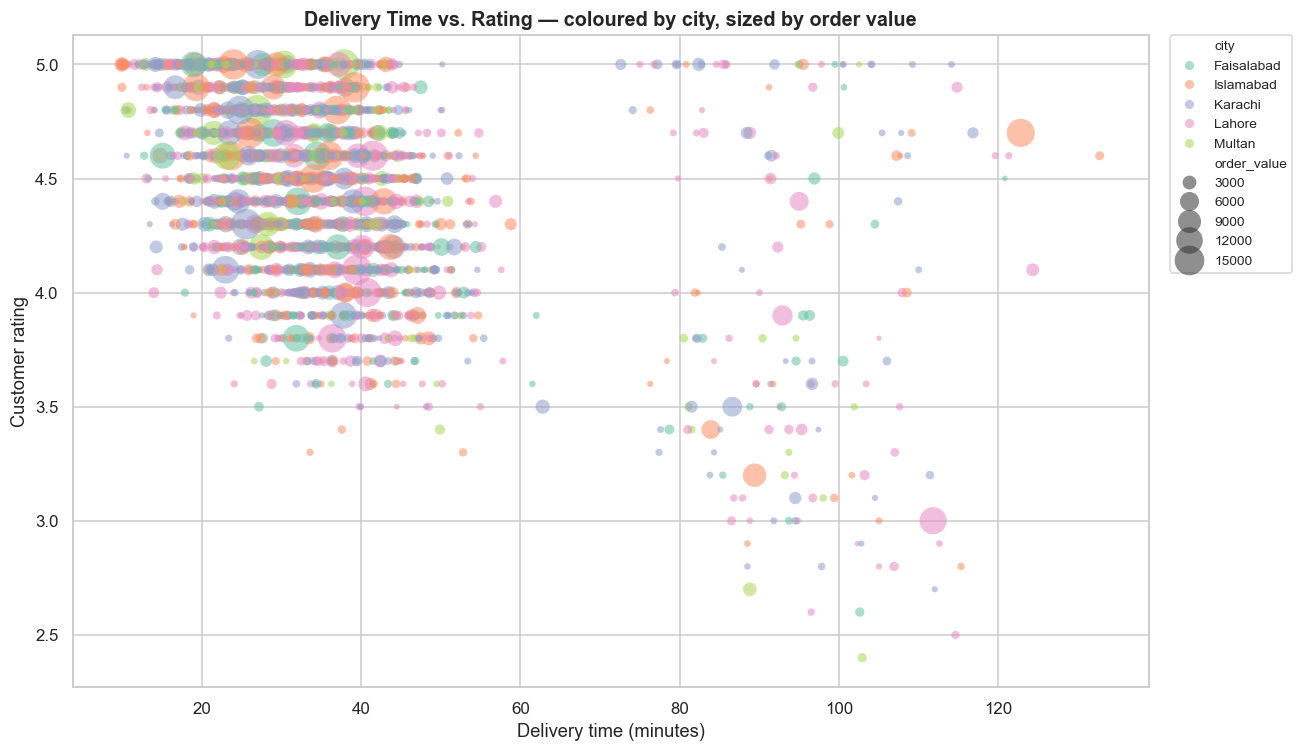

In [15]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(data=clean, x="delivery_time_min", y="rating",
                hue="city", size="order_value",
                sizes=(12, 400), alpha=0.55,
                palette="Set2", edgecolor="none", ax=ax)

ax.set_title("Delivery Time vs. Rating — coloured by city, sized by order value")
ax.set_xlabel("Delivery time (minutes)")
ax.set_ylabel("Customer rating")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left",
          borderaxespad=0, fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
# Quantify what the eye is picking up in the chart above
clean["value_quartile"] = pd.qcut(clean["order_value"], 4,
                                  labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])

summary = (clean.groupby("value_quartile", observed=True)
                .agg(n=("rating", "size"),
                     avg_delivery_min=("delivery_time_min", "mean"),
                     avg_rating=("rating", "mean")))



summary["rating_lost_per_10min"] = np.array(slopes) * 10
summary["corr(time, rating)"] = corrs

print("Does paying more buy you a faster or better-rated delivery?\n")
display(summary.round(3))

print("\nPer-city slope of rating vs. delivery time (rating points per 10 extra minutes):")
for cty, g in clean.groupby("city", observed=True):
    print(f"  {cty:12s} {np.polyfit(g['delivery_time_min'], g['rating'], 1)[0] * 10:+.3f}")

Does paying more buy you a faster or better-rated delivery?



,n,avg_delivery_min,avg_rating,rating_lost_per_10min,"corr(time, rating)"
value_quartile,,,,,
Q1 (lowest),1053,34.589,4.503,-0.122,-0.460
Q2,1047,35.285,4.512,-0.119,-0.454
Q3,1050,34.392,4.497,-0.138,-0.503
Q4 (highest),1050,33.902,4.524,-0.093,-0.359



Per-city slope of rating vs. delivery time (rating points per 10 extra minutes):
  Faisalabad   -0.125
  Islamabad    -0.107
  Karachi      -0.108
  Lahore       -0.124
  Multan       -0.146


---
# Task 4 — Correlation: Pearson vs. Spearman

> Compute both correlation matrices for the numeric columns. Identify the one pair where the two methods
> disagree the most, and determine whether the disagreement is driven by a handful of extreme orders or by
> a genuinely non-linear trend. Decide, and justify, whether those extreme orders should be dropped before
> reporting the correlation to management. Include the correlation-is-not-causation caveat.

In [17]:
pearson  = clean[NUMERIC_COLS].corr(method="pearson")
spearman = clean[NUMERIC_COLS].corr(method="spearman")

print("=== PEARSON (linear, outlier-sensitive) ===")
display(pearson.round(3))

print("=== SPEARMAN (rank-based / monotonic, outlier-robust) ===")
display(spearman.round(3))

=== PEARSON (linear, outlier-sensitive) ===


,order_value,discount_percent,delivery_time_min,rating,profit_per_order
order_value,1.000,-0.011,0.002,0.003,-0.657
discount_percent,-0.011,1.000,0.013,-0.006,-0.082
delivery_time_min,0.002,0.013,1.000,-0.445,-0.031
rating,0.003,-0.006,-0.445,1.000,0.014
profit_per_order,-0.657,-0.082,-0.031,0.014,1.000


=== SPEARMAN (rank-based / monotonic, outlier-robust) ===


,order_value,discount_percent,delivery_time_min,rating,profit_per_order
order_value,1.000,0.008,-0.020,0.004,0.673
discount_percent,0.008,1.000,0.020,-0.003,-0.381
delivery_time_min,-0.020,0.020,1.000,-0.413,-0.109
rating,0.004,-0.003,-0.413,1.000,0.052
profit_per_order,0.673,-0.381,-0.109,0.052,1.000


In [18]:
# Rank every pair by how much the two methods disagree
from itertools import combinations

rows = []
for a, b in combinations(NUMERIC_COLS, 2):
    r_p, r_s = pearson.loc[a, b], spearman.loc[a, b]
    rows.append({"pair": f"{a} ~ {b}", "pearson": r_p, "spearman": r_s,
                 "abs_gap": abs(r_p - r_s),
                 "sign_flip": np.sign(r_p) != np.sign(r_s)})

gaps = pd.DataFrame(rows).sort_values("abs_gap", ascending=False).reset_index(drop=True)
display(gaps.round(3))

worst = gaps.iloc[0]
print(f"\nLargest disagreement: {worst['pair']}")
print(f"  Pearson  = {worst['pearson']:+.3f}")
print(f"  Spearman = {worst['spearman']:+.3f}")
print(f"  Gap      = {worst['abs_gap']:.3f}   |   Sign flip: {worst['sign_flip']}")

,pair,pearson,spearman,abs_gap,sign_flip
0,order_value ~ profit_per_order,-0.657,0.673,1.330,True
1,discount_percent ~ profit_per_order,-0.082,-0.381,0.299,False
2,delivery_time_min ~ profit_per_order,-0.031,-0.109,0.078,False
3,rating ~ profit_per_order,0.014,0.052,0.038,False
4,delivery_time_min ~ rating,-0.445,-0.413,0.033,False
5,order_value ~ delivery_time_min,0.002,-0.020,0.022,True
6,order_value ~ discount_percent,-0.011,0.008,0.019,True
7,discount_percent ~ delivery_time_min,0.013,0.020,0.006,False
8,discount_percent ~ rating,-0.006,-0.003,0.004,False
9,order_value ~ rating,0.003,0.004,0.001,False



Largest disagreement: order_value ~ profit_per_order
  Pearson  = -0.657
  Spearman = +0.673
  Gap      = 1.330   |   Sign flip: True


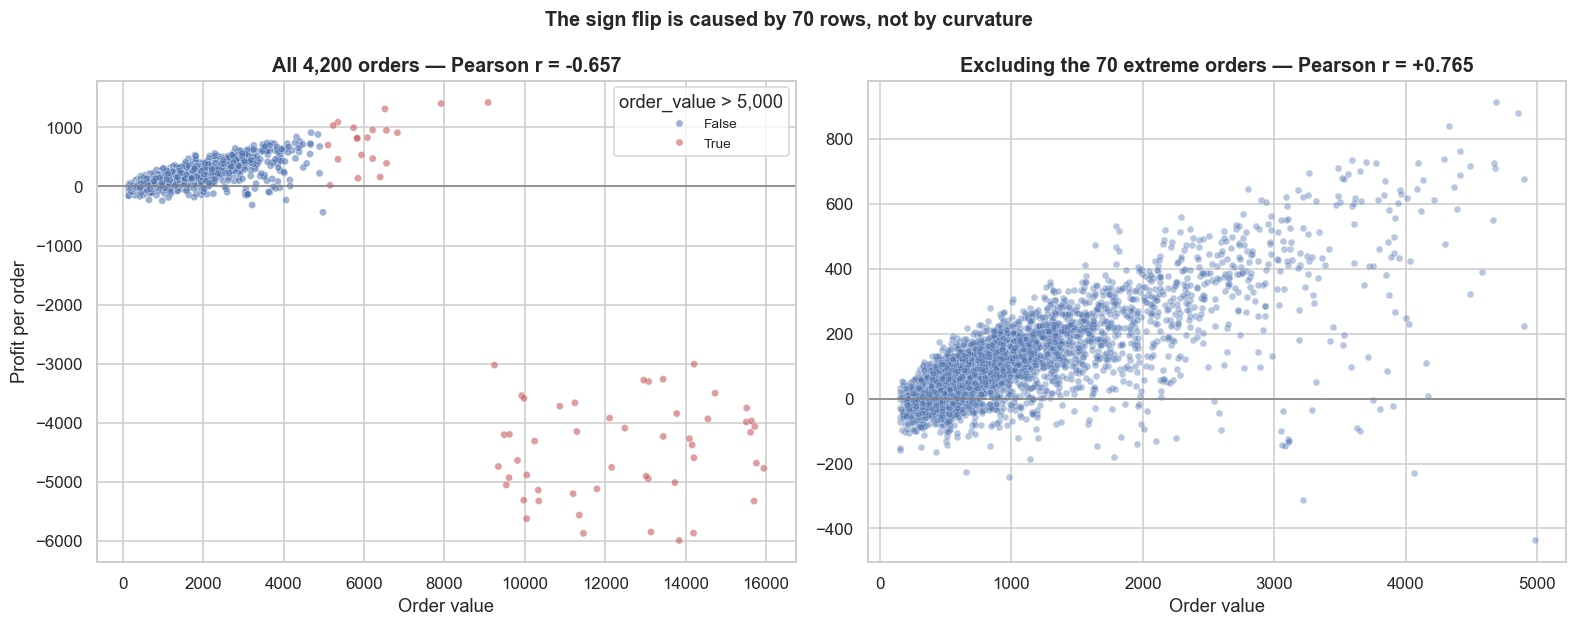

In [19]:
# --- Diagnose: extreme orders, or a genuinely non-linear trend? ----------
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8))

sns.scatterplot(data=clean, x="order_value", y="profit_per_order",
                hue="is_extreme_order", alpha=0.55, s=22,
                palette={False: "#4C72B0", True: "#C44E52"}, ax=axes[0])
axes[0].axhline(0, color="grey", lw=1)
axes[0].set_title("All 4,200 orders — Pearson r = %+.3f" % pearson.loc["order_value", "profit_per_order"])
axes[0].set_xlabel("Order value")
axes[0].set_ylabel("Profit per order")
axes[0].legend(title="order_value > 5,000", fontsize=9)

normal = clean[~clean["is_extreme_order"]]
sns.scatterplot(data=normal, x="order_value", y="profit_per_order",
                alpha=0.4, s=20, color="#4C72B0", ax=axes[1])
axes[1].axhline(0, color="grey", lw=1)
axes[1].set_title("Excluding the 70 extreme orders — Pearson r = %+.3f"
                  % normal["order_value"].corr(normal["profit_per_order"]))
axes[1].set_xlabel("Order value")
axes[1].set_ylabel("")

fig.suptitle("The sign flip is caused by 70 rows, not by curvature",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
ext = clean[clean["is_extreme_order"]]
nrm = clean[~clean["is_extreme_order"]]

print(f"Extreme orders (order_value > {EXTREME_VALUE_CUTOFF:,}):")
print(f"  count                : {len(ext)}  ({len(ext)/len(clean):.2%} of all rows)")
print(f"  mean order_value     : {ext['order_value'].mean():,.0f}")
print(f"  mean profit_per_order: {ext['profit_per_order'].mean():,.0f}")
print(f"  share with a LOSS    : {(ext['profit_per_order'] < 0).mean():.1%}")

print(f"\nRemaining {len(nrm):,} orders:")
print(f"  mean order_value     : {nrm['order_value'].mean():,.0f}")
print(f"  mean profit_per_order: {nrm['profit_per_order'].mean():,.0f}")
print(f"  share with a LOSS    : {(nrm['profit_per_order'] < 0).mean():.1%}")

print("\n" + "-" * 68)
print(f"{'':32s}{'Pearson':>12s}{'Spearman':>12s}")
print(f"{'Full data (n=4,200)':32s}"
      f"{clean['order_value'].corr(clean['profit_per_order']):>+12.3f}"
      f"{clean['order_value'].corr(clean['profit_per_order'], method='spearman'):>+12.3f}")
print(f"{'Extremes excluded (n=4,130)':32s}"
      f"{nrm['order_value'].corr(nrm['profit_per_order']):>+12.3f}"
      f"{nrm['order_value'].corr(nrm['profit_per_order'], method='spearman'):>+12.3f}")
print("-" * 68)

print("\nTen worst-loss orders driving the flip:")
display(ext.nsmallest(10, "profit_per_order")[
    ["order_date", "city", "restaurant_category", "order_value",
     "discount_percent", "profit_per_order"]])

Extreme orders (order_value > 5,000):
  count                : 70  (1.67% of all rows)
  mean order_value     : 10,662
  mean profit_per_order: -2,973
  share with a LOSS    : 71.4%

Remaining 4,130 orders:
  mean order_value     : 987
  mean profit_per_order: 109
  share with a LOSS    : 15.5%

--------------------------------------------------------------------
                                     Pearson    Spearman
Full data (n=4,200)                   -0.657      +0.673
Extremes excluded (n=4,130)           +0.765      +0.732
--------------------------------------------------------------------

Ten worst-loss orders driving the flip:


,order_date,city,restaurant_category,order_value,discount_percent,profit_per_order
3531,2024-04-05,Islamabad,Cafe,"13,838.044",4.100,"-5,994.458"
4000,2024-06-08,Islamabad,Fast Food,"11,456.670",7.300,"-5,873.224"
789,2023-04-12,Karachi,Cafe,"14,196.625",33.600,"-5,869.030"
2873,2024-01-09,Multan,Fast Food,"13,137.047",13.900,"-5,850.113"
831,2023-04-17,Lahore,Fine Dining,"10,045.917",25.100,"-5,625.364"
1954,2023-09-09,Multan,Cloud Kitchen,"11,354.462",0.900,"-5,564.661"
2834,2024-01-03,Islamabad,Dessert,"15,701.281",2.800,"-5,327.070"
3269,2024-03-01,Karachi,Cafe,"10,348.112",0.400,"-5,325.868"
1970,2023-09-11,Karachi,Cloud Kitchen,"9,973.102",3.300,"-5,312.702"
4129,2024-06-22,Faisalabad,Cloud Kitchen,"11,201.946",7.600,"-5,202.626"


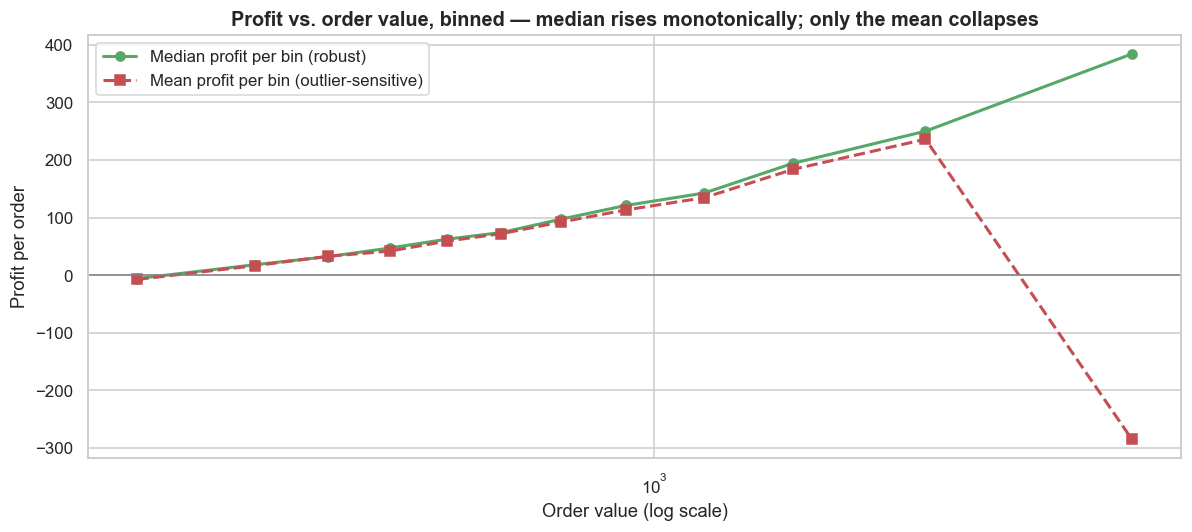

,median_value,median_profit,mean_profit,n
order_value,,,,
"(149.999, 338.917]",286.000,-6.000,-7.500,350
"(338.917, 416.0]",380.000,18.000,16.300,351
"(416.0, 490.0]",453.500,32.000,32.600,352
"(490.0, 562.0]",527.000,47.000,41.700,349
"(562.0, 646.583]",606.000,62.500,59.100,348
"(646.583, 740.5]",691.000,74.000,72.100,350
"(740.5, 860.417]",797.500,97.000,92.000,350
"(860.417, 1030.333]",934.000,121.000,113.200,350
"(1030.333, 1259.25]","1,129.000",142.500,134.400,350


In [21]:
# Non-linearity check: bin order_value and look at median profit per bin.
# A genuinely non-linear trend would bend smoothly; an outlier artefact snaps at the end.
bins = pd.qcut(clean["order_value"], 12, duplicates="drop")
binned = (clean.groupby(bins, observed=True)
               .agg(median_value=("order_value", "median"),
                    median_profit=("profit_per_order", "median"),
                    mean_profit=("profit_per_order", "mean"),
                    n=("profit_per_order", "size")))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(binned["median_value"], binned["median_profit"], "o-",
        lw=2, color="#55A868", label="Median profit per bin (robust)")
ax.plot
plt.show()

display(binned.round(1))

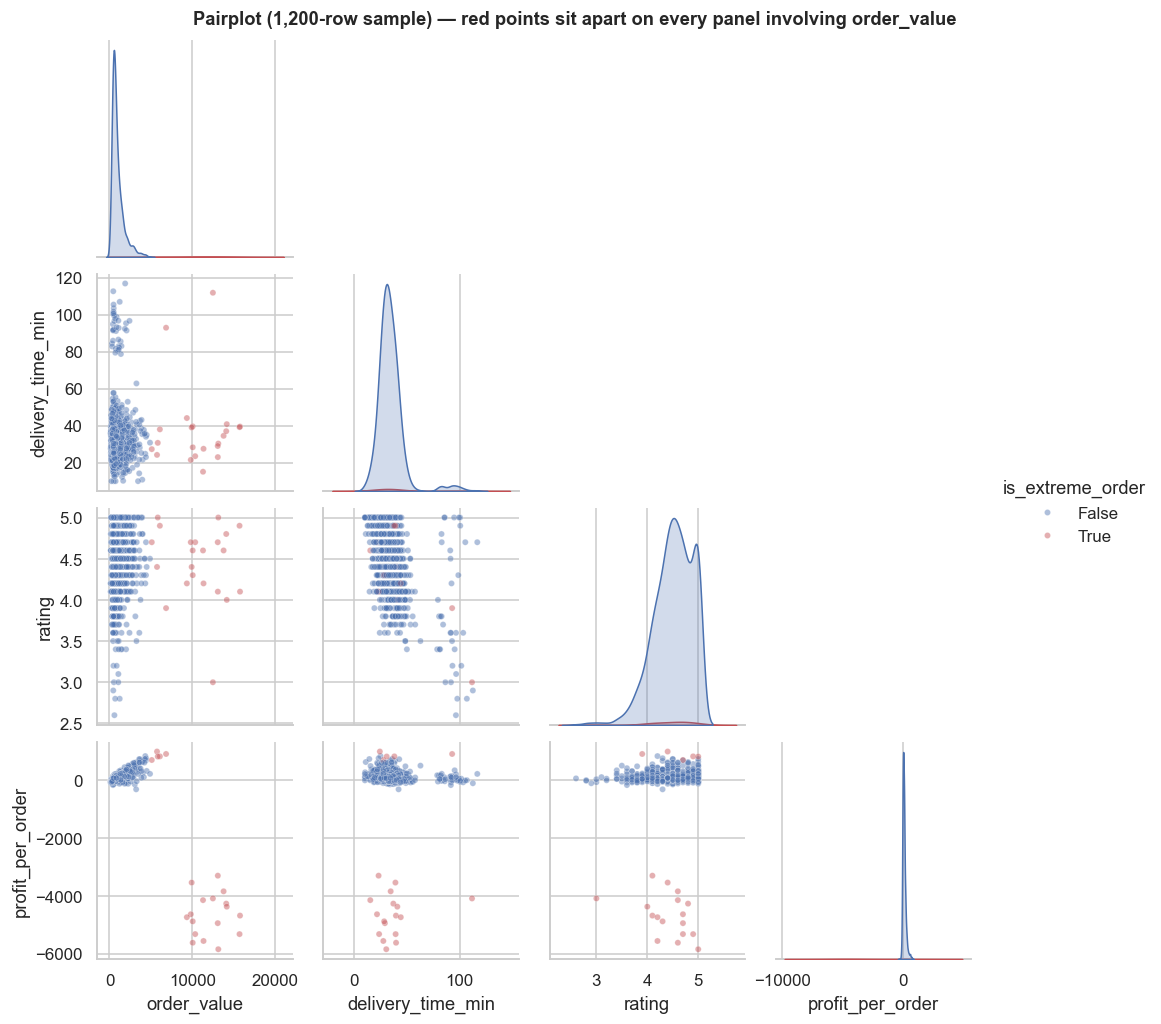

In [22]:
# Supporting multivariate view
sns.pairplot(clean.sample(1200, random_state=42),
             vars=["order_value", "delivery_time_min", "rating", "profit_per_order"],
             hue="is_extreme_order", corner=True, plot_kws=dict(alpha=0.45, s=16),

plt.show()

---
# Task 5 — Layered aggregation

> Using `pivot_table`, build a `city` × `restaurant_category` table of **average `profit_per_order`**
> (not total revenue) with `margins=True`. Render it as a heatmap with a **diverging** palette (profit can
> be negative) and state which combination is most profitable per order. Note whether that combination is
> also the top revenue generator.

In [23]:
profit_pivot = pd.pivot_table(clean,
                              index="city", columns="restaurant_category",
                              values="profit_per_order", aggfunc="mean",
                              margins=True, margins_name="ALL",
                              observed=True)

print("Average profit per order — city × restaurant_category (margins = overall averages)\n")
display(profit_pivot.round(1))

Average profit per order — city × restaurant_category (margins = overall averages)



restaurant_category,Cafe,Cloud Kitchen,Dessert,Fast Food,Fine Dining,ALL
city,,,,,,
Faisalabad,67.300,65.800,-70.300,20.200,293.700,51.900
Islamabad,-13.500,57.000,-27.900,37.200,153.100,35.500
Karachi,-38.900,136.700,75.200,15.400,302.800,74.100
Lahore,52.300,137.600,65.500,10.600,159.800,71.600
Multan,60.100,-82.800,55.900,-40.800,285.200,12.600
ALL,14.600,91.800,31.300,13.600,228.900,57.400


In [24]:
# Multi-statistic version — the layered aggregation the manual asks for
layered = (clean.groupby(["city", "restaurant_category"], observed=True)
                .agg(orders=("profit_per_order", "size"),
                     avg_profit=("profit_per_order", "mean"),
                     median_profit=("profit_per_order", "median"),
                     total_profit=("profit_per_order", "sum"),
                     total_revenue=("order_value", "sum"),
                     avg_rating=("rating", "mean")))

print("Top 5 combinations by AVERAGE profit per order:")
display(layered.sort_values("avg_profit", ascending=False).head(5).round(1))

print("Top 5 combinations by TOTAL REVENUE:")
display(layered.sort_values("total_revenue", ascending=False).head(5).round(1))

Top 5 combinations by AVERAGE profit per order:


,,orders,avg_profit,median_profit,total_profit,total_revenue,avg_rating
city,restaurant_category,,,,,,
Karachi,Fine Dining,141,302.800,272.000,"42,695.000","371,893.000",4.600
Faisalabad,Fine Dining,46,293.700,234.500,"13,510.000","123,173.000",4.500
Multan,Fine Dining,33,285.200,264.000,"9,411.000","81,485.000",4.600
Lahore,Fine Dining,122,159.800,245.000,"19,497.800","336,923.800",4.500
Islamabad,Fine Dining,90,153.100,236.500,"13,780.600","270,610.200",4.500


Top 5 combinations by TOTAL REVENUE:


orders  avg_profit  median_profit  total_profit  total_revenue  avg_rating
city      restaurant_category                                                                            
Lahore    Cloud Kitchen           324     137.600        131.500    44,587.000    449,766.600       4.500
          Fast Food               430      10.600         60.000     4,566.000    379,476.900       4.500
Karachi   Fine Dining             141     302.800        272.000    42,695.000    371,893.000       4.600
          Cloud Kitchen           266     136.700        122.000    36,374.300    371,410.100       4.500
Islamabad Cloud Kitchen           205      57.000        141.000    11,687.300    342,842.300       4.500

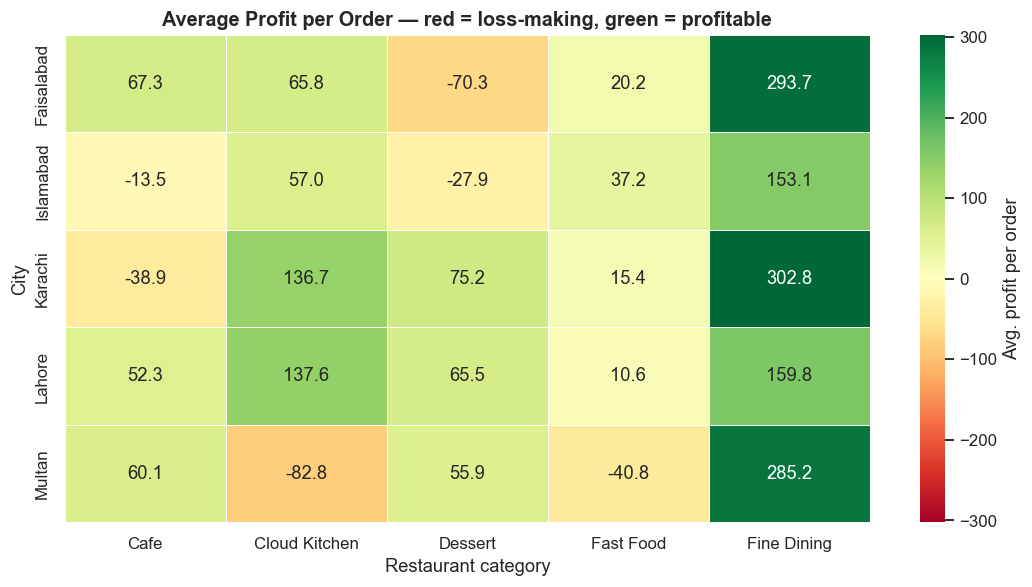

In [25]:
# Heatmap — diverging palette centred on zero, because profit can be negative (Lab 3 rule)
grid = profit_pivot.drop(index="ALL", columns="ALL")
lim = np.abs(grid.values).max()

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(grid, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, vmin=-lim, vmax=lim,
            linewidths=0.6, linecolor="white",
            cbar_kws={"label": "Avg. profit per order"}, ax=ax)

ax.set_title("Average Profit per Order — red = loss-making, green = profitable")
ax.set_xlabel("Restaurant category")
ax.set_ylabel("City")
plt.tight_layout()
plt.show()

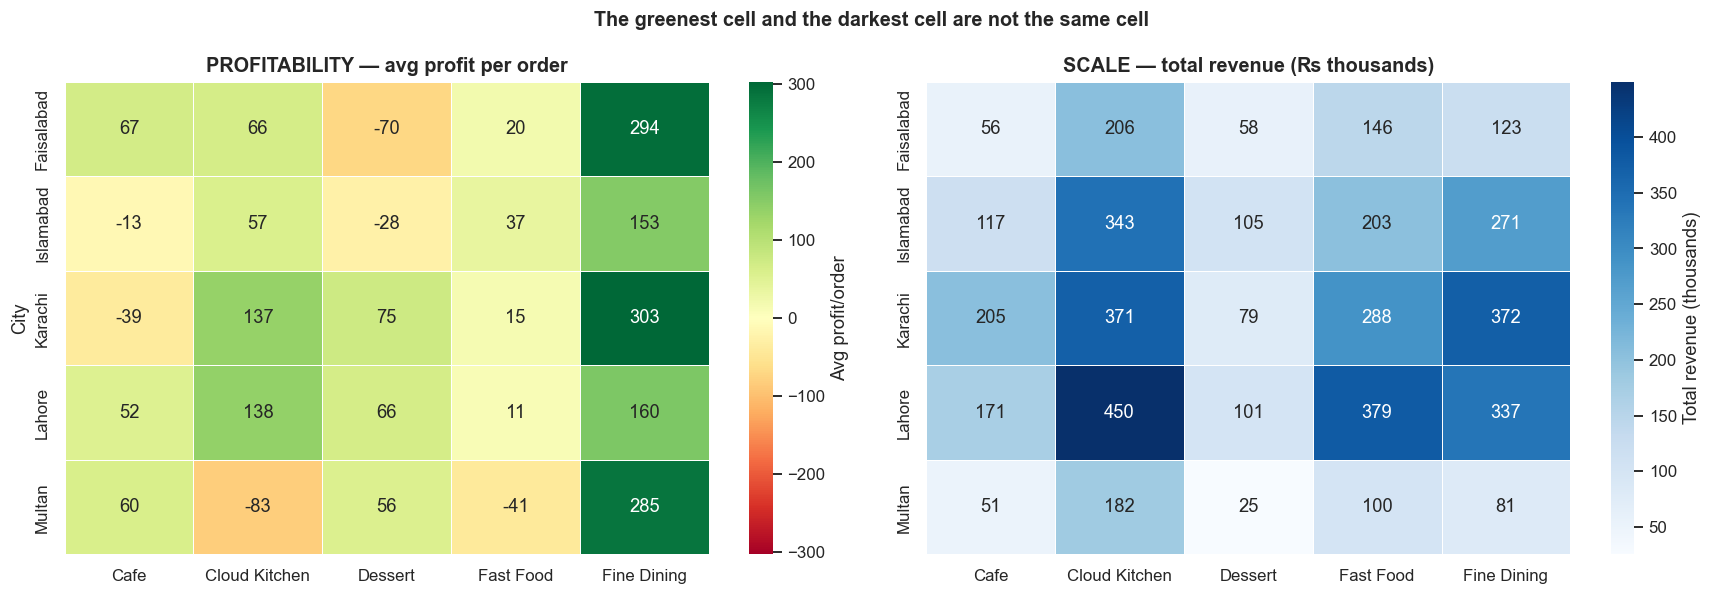

Most profitable per order : Karachi × Fine Dining  (₨303 avg/order)
Top revenue generator     : Lahore × Cloud Kitchen  (₨449,767 total)


In [26]:
# Side-by-side: profitability vs. revenue scale — do they point to the same cell?
revenue_pivot = pd.pivot_table(clean, index="city", columns="restaurant_category",
                               values="order_value", aggfunc="sum",
                               observed=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

sns.heatmap(grid, annot=True, fmt=".0f", cmap="RdYlGn", center=0,
            vmin=-lim, vmax=lim, linewidths=0.6, linecolor="white",
            cbar_kws={"label": "Avg profit/order"}, ax=axes[0])
axes[0].set_title("PROFITABILITY — avg profit per order")
axes[0].set_xlabel(""); axes[0].set_ylabel("City")

sns.heatmap(revenue_pivot / 1000, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.6, linecolor="white",
            cbar_kws={"label": "Total revenue (thousands)"}, ax=axes[1])
axes[1].set_title("SCALE — total revenue (₨ thousands)")
axes[1].set_xlabel(""); axes[1].set_ylabel("")

fig.suptitle("The greenest cell and the darkest cell are not the same cell",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

best_profit = grid.stack().idxmax()
best_revenue = revenue_pivot.stack().idxmax()
print(f"Most profitable per order : {best_profit[0]} × {best_profit[1]}  "
      f"(₨{grid.stack().max():,.0f} avg/order)")
print(f"Top revenue generator     : {best_revenue[0]} × {best_revenue[1]}  "
      f"(₨{revenue_pivot.stack().max():,.0f} total)")

### Answer — Task 5

**Most profitable combination per order: Karachi × Fine Dining, at ₨302.8 average profit per order** —
more than five times the company-wide average of ₨57.4. Fine Dining is the strongest category overall
(₨228.9 per order in the margins row) and is profitable in all five cities.

**No — the most profitable combination is not the top revenue generator.** The highest-revenue cell is
**Lahore × Cloud Kitchen at ₨449,767 total**, which earns only ₨137.6 per order; Karachi × Fine Dining
turns over ₨371,893, about 17% less. High revenue is coming from **volume in Cloud Kitchen and Fast Food**,
while margin is coming from **Fine Dining**, and the two heatmaps above point at different cells.

The diverging palette also surfaces what a sequential one would have flattened: **six of the 25
combinations are loss-making**, worst of all **Multan × Cloud Kitchen (−₨82.8/order)** and
**Multan × Fast Food (−₨40.8/order)** — the same Cloud Kitchen and Fast Food categories that are
comfortably profitable in Lahore and Karachi. Multan is the operational problem, not the categories.

---
# Task 6 — Time-series: trend vs. noise

> Resample the data to get **average monthly rating** (not sales) and overlay a **3-month rolling average**.
> State whether customer satisfaction is trending up, down, or flat once month-to-month noise is smoothed,
> and whether the raw monthly line alone would have led to a different conclusion.

*Rule from the manual: **resample first, then roll.** Rolling over raw transaction rows would average across
irregular gaps, because the number of orders per day is not constant.*

In [27]:
ts = clean.set_index("order_date").sort_index()

monthly = ts["rating"].resample("ME").mean()          # step 1: resample
rolling = monthly.rolling(window=3).mean()            # step 2: then roll

trend = pd.DataFrame({"monthly_avg_rating": monthly,
                      "rolling_3mo": rolling,
                      "n_orders": ts["rating"].resample("ME").size()})
trend.index = trend.index.to_period("M")
display(trend.round(3))

,monthly_avg_rating,rolling_3mo,n_orders
order_date,,,
2023-01,4.537,NaN,221
2023-02,4.504,NaN,214
2023-03,4.536,4.526,263
2023-04,4.545,4.528,235
2023-05,4.504,4.528,227
2023-06,4.513,4.521,245
2023-07,4.534,4.517,213
2023-08,4.505,4.517,251
2023-09,4.505,4.515,249


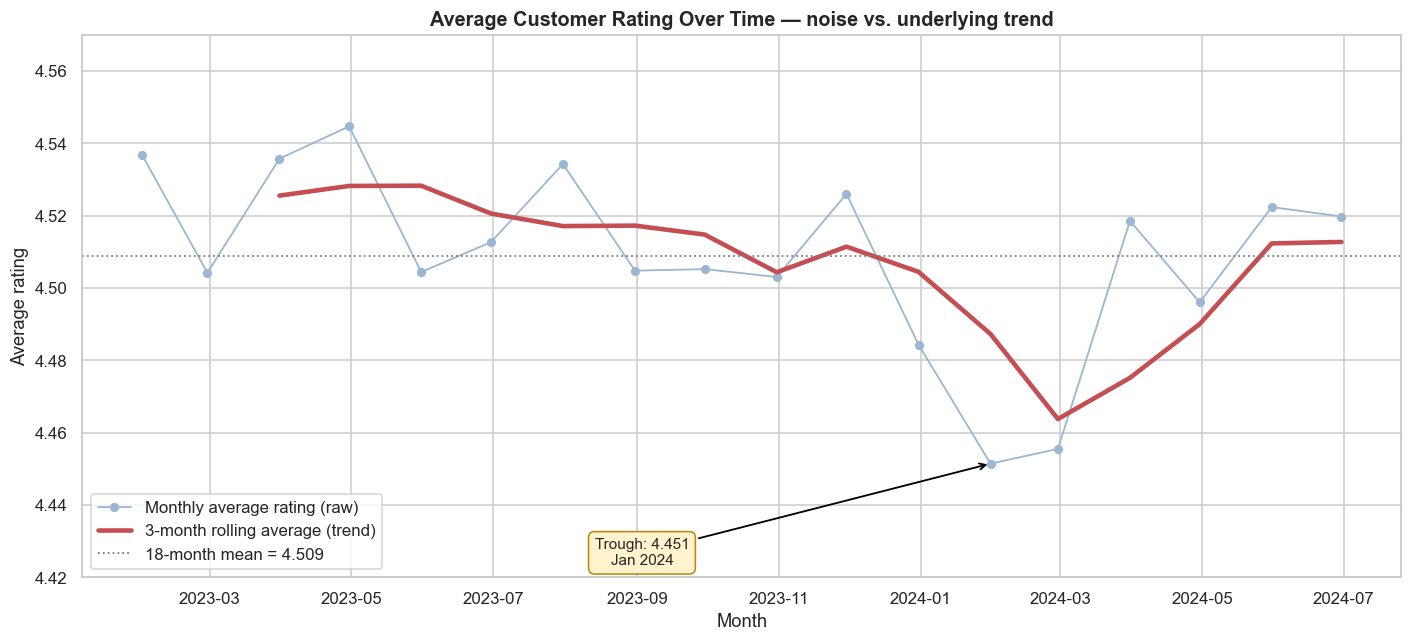

In [28]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(monthly.index, monthly.values, marker="o", ms=5, lw=1.2,
        color="#9BB7D4", label="Monthly average rating (raw)")
ax.plot(rolling.index, rolling.values, lw=3, color="#C44E52",
        label="3-month rolling average (trend)")

ax.axhline(monthly.mean(), color="grey", ls=":", lw=1.2,
           label=f"18-month mean = {monthly.mean():.3f}")

trough = monthly.idxmin()
ax.annotate(f"Trough: {monthly.min():.3f}\n{trough:%b %Y}",
            xy=(trough, monthly.min()),
            xytext=(trough - pd.Timedelta(days=150), monthly.min() - 0.028),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
            fontsize=10, ha="center",
            bbox=dict(boxstyle="round,pad=0.4", fc="#FFF3CD", ec="#B8860B"))

ax.set_title("Average Customer Rating Over Time — noise vs. underlying trend")
ax.set_xlabel("Month")
ax.set_ylabel("Average rating")
ax.set_ylim(4.42, 4.57)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [29]:
x = np.arange(len(monthly))
slope, intercept = np.polyfit(x, monthly.values, 1)

print(f"Linear trend slope        : {slope:+.5f} rating points / month")
print(f"Implied change over 18 mo : {slope * 17:+.4f} rating points")
print(f"Month-to-month volatility : {monthly.diff().abs().mean():.4f} (raw)  "
      f"vs {rolling.diff().abs().mean():.4f} (smoothed)")
print(f"Raw range                 : {monthly.min():.3f} - {monthly.max():.3f} "
      f"(spread {monthly.max() - monthly.min():.3f})")
print(f"Smoothed range            : {rolling.min():.3f} - {rolling.max():.3f} "
      f"(spread {rolling.max() - rolling.min():.3f})")
print(f"\nFirst 3 months mean       : {monthly[:3].mean():.3f}")
print(f"Last 3 months mean        : {monthly[-3:].mean():.3f}")
print(f"Biggest single-month jump : {monthly.diff().abs().max():.3f} "
      f"({monthly.diff().abs().idxmax():%b %Y})")

Linear trend slope        : -0.00193 rating points / month
Implied change over 18 mo : -0.0329 rating points
Month-to-month volatility : 0.0230 (raw)  vs 0.0087 (smoothed)
Raw range                 : 4.451 - 4.545 (spread 0.093)
Smoothed range            : 4.464 - 4.528 (spread 0.065)

First 3 months mean       : 4.526
Last 3 months mean        : 4.513
Biggest single-month jump : 0.063 (Mar 2024)


### Answer — Task 6

**Customer satisfaction is essentially flat, with a shallow dip-and-recovery rather than a trend.** The
smoothed line drifts from 4.526 in early 2023 down to a floor of 4.464 around February 2024, then climbs
back to 4.513 by June 2024 — a total swing of 0.049 rating points on a 5-point scale, and a fitted slope of
just −0.0019 points per month (about −0.033 over the whole 18 months). The winter 2023-24 softening is the
only real signal in the series, and it has already been recovered.

**Yes, the raw monthly line alone would have led to a different conclusion.** The unsmoothed series jumps
around by an average of 0.023 points per month and spans 4.451 to 4.545 — roughly twice the smoothed
range. Reading it in isolation invites two wrong calls: the December-2023-to-February-2024 stretch
(4.484 → 4.451 → 4.456) looks like the start of a sustained decline, and the single-month leap from
February to March 2024 (4.456 → 4.519, the largest jump in the series at +0.063) looks like a dramatic
recovery worth attributing to something. The rolling average shows both are the same shallow dip seen at
different moments, and that neither the fall nor the rebound was as sharp as the raw line implies.

---
# Task 7 — Faceting

> Using `FacetGrid` or `catplot`, facet `delivery_time_min` vs. `rating` scatter plots by
> `restaurant_category` (**col**) and by whether the order was heavily discounted,
> `discount_percent > 20` (**hue**). State one `restaurant_category` where heavy discounting visibly
> changes how forgiving customers are of a slow delivery.

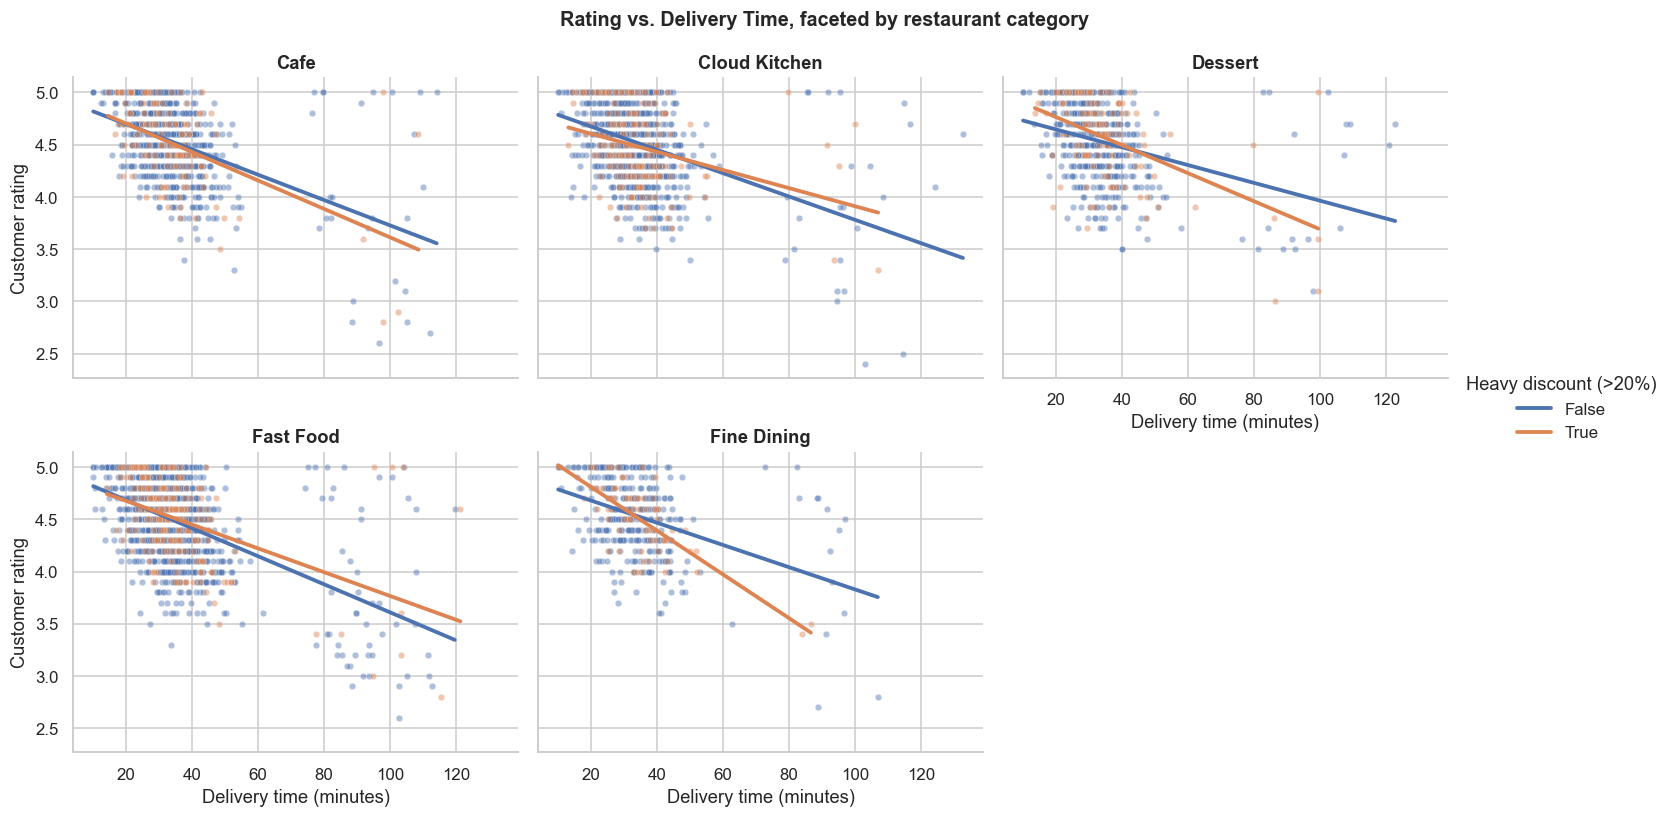

In [30]:
g = sns.FacetGrid(clean, col="restaurant_category", hue="heavy_discount",
                  col_wrap=3, height=3.6, aspect=1.25,
                  palette={False: "#4C72B0", True: "#DD8452"},
                  hue_order=[False, True])

g.map(sns.scatterplot, "delivery_time_min", "rating", alpha=0.45, s=18)
g.map(sns.regplot, "delivery_time_min", "rating",
      scatter=False, ci=None, line_kws={"lw": 2.5})

g.set_axis_labels("Delivery time (minutes)", "Customer rating")
g.set_titles("{col_name}")
g.add_legend(title="Heavy discount (>20%)")
g.figure.suptitle("Rating vs. Delivery Time, faceted by restaurant category",
                  y=1.03, fontsize=13, fontweight="bold")
plt.show()

In [31]:
# Quantify the visual: slope of rating vs. delivery time, per category × discount group
rows = []
for cat, g_ in clean.groupby("restaurant_category", observed=True):
    for heavy, gg in g_.groupby("heavy_discount", observed=True):
        rows.append({"restaurant_category": cat, "heavy_discount": heavy,
                     "n": len(gg),
                     "rating_lost_per_10min": np.polyfit(gg["delivery_time_min"],
                                                         gg["rating"], 1)[0] * 10,
                     "corr": gg["delivery_time_min"].corr(gg["rating"])})

slope_tbl = pd.DataFrame(rows)
wide = slope_tbl.pivot(index="restaurant_category",
                       columns="heavy_discount",
                       values="rating_lost_per_10min")
wide.columns = ["normal_price", "heavy_discount"]
wide["difference"] = wide["heavy_discount"] - wide["normal_price"]
wide["n_heavy"] = slope_tbl[slope_tbl["heavy_discount"]].set_index("restaurant_category")["n"]

print("Rating points lost per 10 extra minutes of delivery time")
print("(more negative = customers are LESS forgiving)\n")
display(wide.sort_values("difference").round(4))

Rating points lost per 10 extra minutes of delivery time
(more negative = customers are LESS forgiving)



,normal_price,heavy_discount,difference,n_heavy
restaurant_category,,,,
Fine Dining,-0.106,-0.209,-0.103,70
Dessert,-0.085,-0.134,-0.049,116
Cafe,-0.121,-0.136,-0.015,126
Fast Food,-0.134,-0.114,0.020,215
Cloud Kitchen,-0.112,-0.087,0.025,163


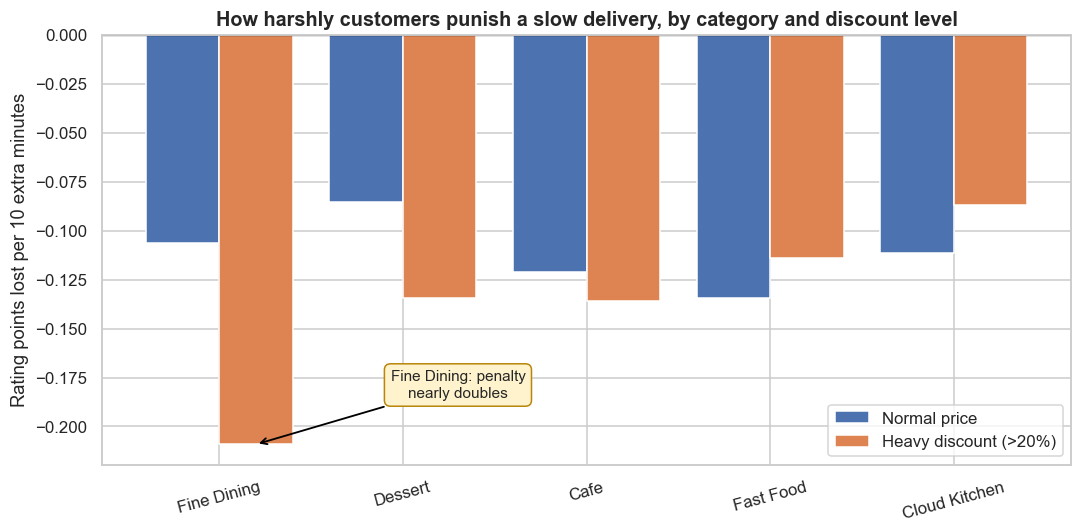

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
w = wide.sort_values("difference")
xpos = np.arange(len(w))

ax.bar(xpos - 0.2, w["normal_price"], 0.4, label="Normal price", color="#4C72B0")
ax.bar(xpos + 0.2, w["heavy_discount"], 0.4, label="Heavy discount (>20%)", color="#DD8452")

ax.set_xticks(xpos)
ax.set_xticklabels(w.index, rotation=15)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Rating points lost per 10 extra minutes")
ax.set_title("How harshly customers punish a slow delivery, by category and discount level")
ax.legend()

ax.annotate("Fine Dining: penalty\nnearly doubles",
            xy=(0.2, w.loc["Fine Dining", "heavy_discount"]),
            xytext=(1.3, -0.185),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
            fontsize=10, ha="center",
            bbox=dict(boxstyle="round,pad=0.4", fc="#FFF3CD", ec="#B8860B"))

plt.tight_layout()
plt.show()

### Answer — Task 7

**Fine Dining is the category where heavy discounting visibly changes how forgiving customers are — and it
makes them markedly *less* forgiving.**

At normal prices, a Fine Dining customer's rating falls **0.106 points per 10 extra minutes**
(r = −0.40), close to the dataset average. On heavily discounted Fine Dining orders the same penalty rises
to **0.209 points per 10 minutes** (r = −0.74) — nearly double the slope, and by far the steepest and
tightest relationship anywhere in the facet grid. The Fine Dining panel is the only one where the orange
regression line is visibly steeper than the blue one; in Cloud Kitchen and Fast Food the discounted line is
actually slightly *flatter*, i.e. a discount buys a little patience there.

The plausible reading is that a discount does not lower expectations at the premium end — it raises them.
A customer who took a >20% promotion on an expensive meal still expects a premium experience and reacts
sharply when the delivery is slow, whereas a Fast Food customer treats the discount as compensation.

**Caveat worth stating:** only 70 of the 4,200 orders are heavily discounted Fine Dining orders, the
smallest of the ten groups in the table, so the steep slope should be treated as a hypothesis for
follow-up rather than a settled finding.

---
# Task 8 — Overplotting + annotation, combined

> Plot the raw order-level `delivery_time_min` vs. `rating` scatter (expect heavy overplotting from
> repeated rating values). Fix it using alpha or hexbin, whichever suits the point count better, and
> **justify the choice**. Then annotate the order with the **best rating despite an unusually long
> delivery**, and the order with the **worst rating despite an unusually fast delivery**.

In [33]:
print(f"Total points               : {len(clean):,}")
print(f"Distinct rating values     : {clean['rating'].nunique()}  "
      f"(→ ratings fall on {clean['rating'].nunique()} horizontal bands, not a continuum)")
print(f"Distinct delivery times    : {clean['delivery_time_min'].nunique():,}")
print(f"Most crowded rating value  : {clean['rating'].value_counts().idxmax()} "
      f"({clean['rating'].value_counts().max()} orders on that single line)")

Total points               : 4,200
Distinct rating values     : 27  (→ ratings fall on 27 horizontal bands, not a continuum)
Distinct delivery times    : 560
Most crowded rating value  : 5.0 (668 orders on that single line)


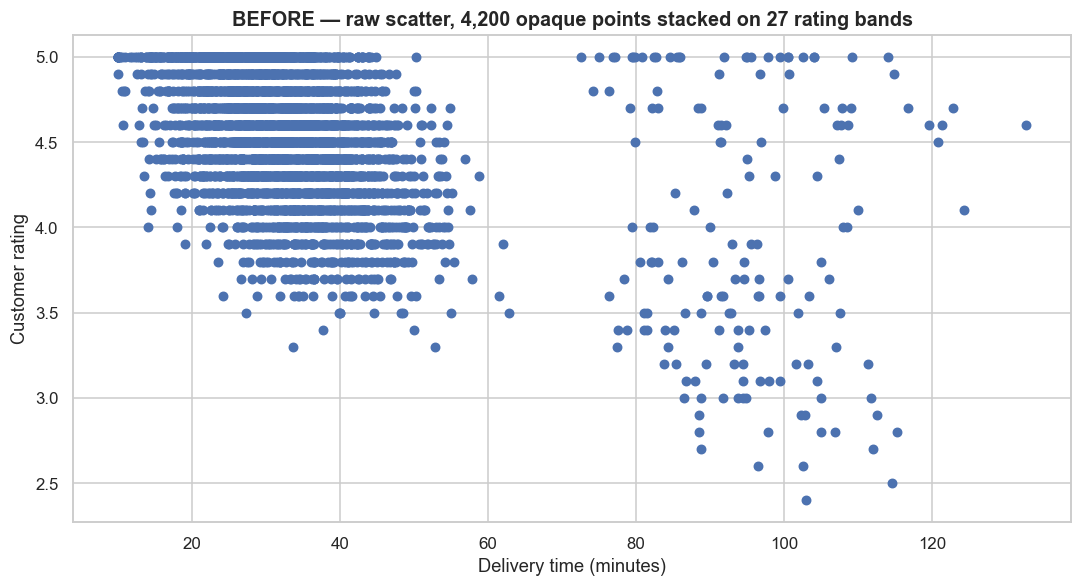

In [34]:
# Step 1: the broken plot — this is what overplotting looks like
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(clean["delivery_time_min"], clean["rating"], s=30, color="#4C72B0")
ax.set_title("BEFORE — raw scatter, 4,200 opaque points stacked on 27 rating bands")
ax.set_xlabel("Delivery time (minutes)")
ax.set_ylabel("Customer rating")
plt.tight_layout()
plt.show()

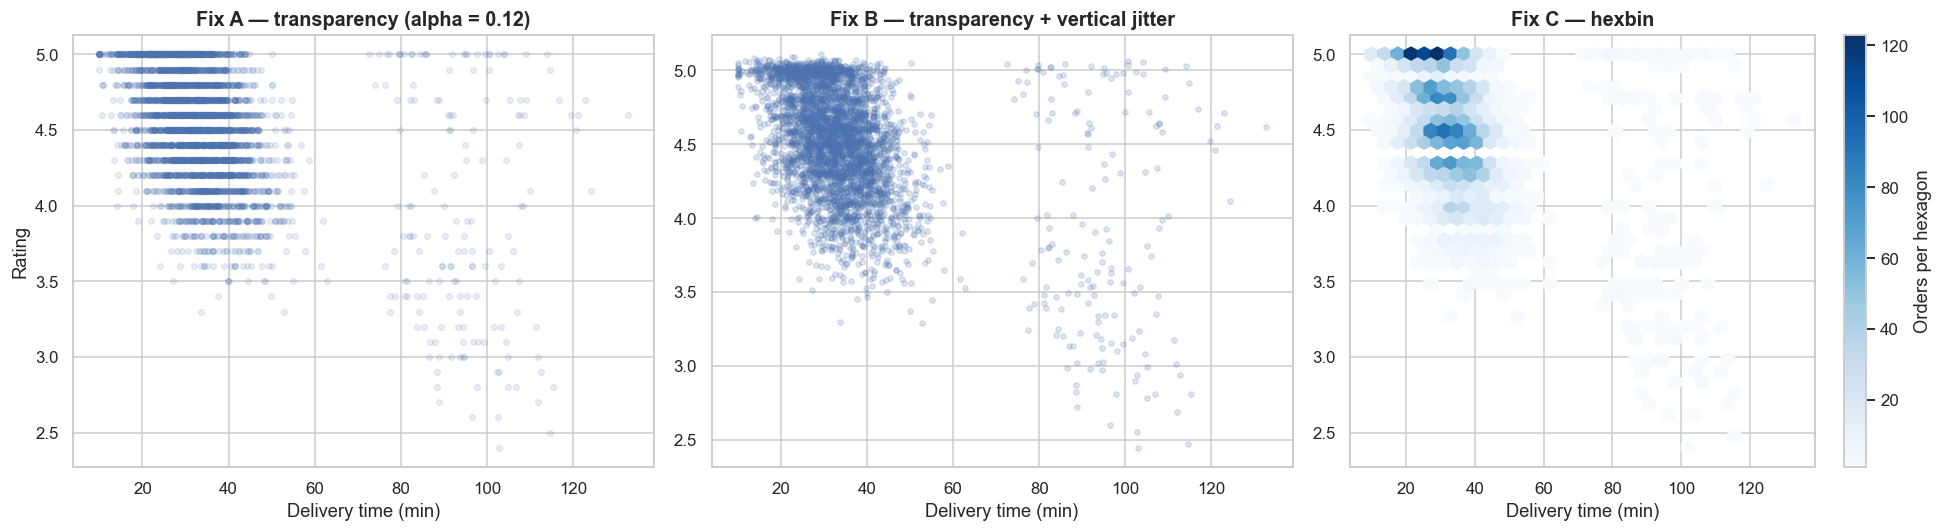

In [35]:
# Step 2: the three candidate fixes, side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(clean["delivery_time_min"], clean["rating"],
                s=14, alpha=0.12, color="#4C72B0")
axes[0].set_title("Fix A — transparency (alpha = 0.12)")
axes[0].set_xlabel("Delivery time (min)")
axes[0].set_ylabel("Rating")

rng = np.random.default_rng(42)
jitter = rng.normal(0, 0.035, len(clean))
axes[1].scatter(clean["delivery_time_min"], clean["rating"] + jitter,
                s=12, alpha=0.18, color="#4C72B0")
axes[1].set_title("Fix B — transparency + vertical jitter")
axes[1].set_xlabel("Delivery time (min)")

hb = axes[2].hexbin(clean["delivery_time_min"], clean["rating"],
                    gridsize=32, cmap="Blues", mincnt=1)
fig.colorbar(hb, ax=axes[2], label="Orders per hexagon")
axes[2].set_title("Fix C — hexbin")
axes[2].set_xlabel("Delivery time (min)")

plt.tight_layout()
plt.show()

**Justification of the chosen fix — transparency plus jitter (Fix B).**

At **4,200 points** we sit squarely in the manual's "moderate overlap, a few thousand points" band, where
alpha is the recommended tool; hexbin is reserved for 50k+ and here it throws away the individual points
that Task 8's annotation step actually needs. The complicating factor is that `rating` takes only **27
distinct values**, so every order lands on one of 27 horizontal lines and up to 668 orders stack on a
single line — alpha alone cannot separate points that are *exactly* coincident. Adding a small vertical
jitter (σ = 0.035, well under the 0.1 rating step) breaks those ties, and the two together show the density
gradient *and* keep every order individually addressable for annotation. Hexbin (Fix C) renders the density
most cleanly of the three, but it aggregates points into bins, which makes it impossible to point an arrow
at one specific order.

In [36]:
# Step 3: identify the two orders to annotate ---------------------------
slow_cut = clean["delivery_time_min"].quantile(0.90)   # "unusually long"
fast_cut = clean["delivery_time_min"].quantile(0.10)   # "unusually fast"

print(f"'Unusually long'  = above the 90th percentile = {slow_cut:.1f} min")
print(f"'Unusually fast'  = below the 10th percentile = {fast_cut:.1f} min\n")

slow_orders = clean[clean["delivery_time_min"] >= slow_cut]
fast_orders = clean[clean["delivery_time_min"] <= fast_cut]

# Best rating among the slowest; tie-break on the longest delivery
best_despite_slow = slow_orders.sort_values(
    ["rating", "delivery_time_min"], ascending=[False, False]).iloc[0]

# Worst rating among the fastest; tie-break on the fastest delivery
worst_despite_fast = fast_orders.sort_values(
    ["rating", "delivery_time_min"], ascending=[True, True]).iloc[0]

print("BEST rating despite an unusually LONG delivery:")
print(best_despite_slow[["order_date", "city", "restaurant_category", "cuisine",
                         "order_value", "discount_percent",
                         "delivery_time_min", "rating"]].to_string(), end="\n\n")

print("WORST rating despite an unusually FAST delivery:")
print(worst_despite_fast[["order_date", "city", "restaurant_category", "cuisine",
                          "order_value", "discount_percent",
                          "delivery_time_min", "rating"]].to_string())

'Unusually long'  = above the 90th percentile = 44.4 min
'Unusually fast'  = below the 10th percentile = 22.0 min

BEST rating despite an unusually LONG delivery:
order_date             2024-04-30 00:00:00
city                               Karachi
restaurant_category                   Cafe
cuisine                             Bakery
order_value                        507.000
discount_percent                    17.700
delivery_time_min                  114.100
rating                               5.000

WORST rating despite an unusually FAST delivery:
order_date             2024-02-11 00:00:00
city                             Islamabad
restaurant_category                Dessert
cuisine                              Cakes
order_value                        339.000
discount_percent                    38.200
delivery_time_min                   19.000
rating                               3.900


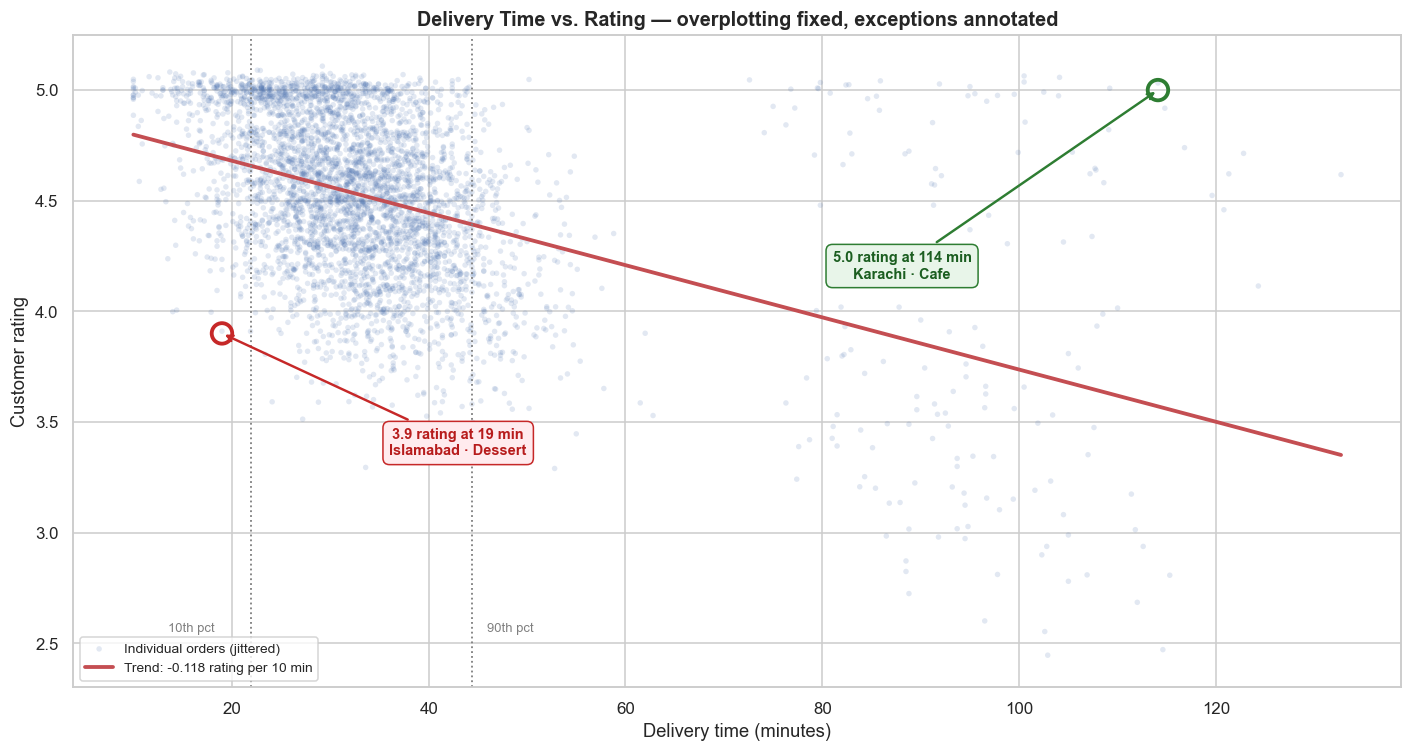

In [37]:
# Step 4: the final fixed + annotated chart -----------------------------
fig, ax = plt.subplots(figsize=(13, 7))

ax.scatter(clean["delivery_time_min"], clean["rating"] + jitter,
           s=13, alpha=0.16, color="#4C72B0",
           edgecolors="none", label="Individual orders (jittered)")

# Trend line through the cloud
z = np.polyfit(clean["delivery_time_min"], clean["rating"], 1)
xs = np.linspace(clean["delivery_time_min"].min(), clean["delivery_time_min"].max(), 100)
ax.plot(xs, np.polyval(z, xs), color="#C44E52", lw=2.5,
        label=f"Trend: {z[0]*10:+.3f} rating per 10 min")

ax.axvline(slow_cut, color="grey", ls=":", lw=1.2)
ax.axvline(fast_cut, color="grey", ls=":", lw=1.2)
ax.text(slow_cut + 1.5, 2.55, "90th pct", fontsize=8.5, color="grey")
ax.text(fast_cut - 8.5, 2.55, "10th pct", fontsize=8.5, color="grey")

# --- Annotation 1: forgiving customer, very slow delivery ---
ax.scatter(best_despite_slow["delivery_time_min"], best_despite_slow["rating"],
           s=180, facecolor="none", edgecolor="#2E7D32", lw=2.5, zorder=5)
ax.annotate(f"5.0 rating at {best_despite_slow['delivery_time_min']:.0f} min\n"
            f"{best_despite_slow['city']} · {best_despite_slow['restaurant_category']}",
            xy=(best_despite_slow["delivery_time_min"], best_despite_slow["rating"]),
            xytext=(best_despite_slow["delivery_time_min"] - 26, 4.15),
            arrowprops=dict(arrowstyle="->", color="#2E7D32", lw=1.6),
            fontsize=9.5, ha="center", color="#1B5E20", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.45", fc="#E8F5E9", ec="#2E7D32"))

# --- Annotation 2: harsh customer, very fast delivery ---
ax.scatter(worst_despite_fast["delivery_time_min"], worst_despite_fast["rating"],
           s=180, facecolor="none", edgecolor="#C62828", lw=2.5, zorder=5)
ax.annotate(f"{worst_despite_fast['rating']:.1f} rating at "
            f"{worst_despite_fast['delivery_time_min']:.0f} min\n"
            f"{worst_despite_fast['city']} · {worst_despite_fast['restaurant_category']}",
            xy=(worst_despite_fast["delivery_time_min"], worst_despite_fast["rating"]),
            xytext=(worst_despite_fast["delivery_time_min"] + 24, 3.35),
            arrowprops=dict(arrowstyle="->", color="#C62828", lw=1.6),
            fontsize=9.5, ha="center", color="#B71C1C", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.45", fc="#FFEBEE", ec="#C62828"))

ax.set_title("Delivery Time vs. Rating — overplotting fixed, exceptions annotated",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Delivery time (minutes)")
ax.set_ylabel("Customer rating")
ax.set_ylim(2.3, 5.25)
ax.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

### Answer — Task 8

**Overplotting diagnosis and fix.** The raw scatter renders as 27 solid horizontal bars rather than a
cloud, because `rating` is recorded to one decimal place and 4,200 orders collapse onto only 27 distinct
values — 668 of them on the single most crowded line (rating 5.0). The fix used is **alpha = 0.16 combined with a small
vertical jitter (σ = 0.035)**: at four thousand points alpha is the technique the manual prescribes, and
jitter is needed on top of it because transparency cannot separate points that are exactly coincident.
Hexbin was rejected despite rendering the density well, since binning the points away would have made the
two required annotations impossible to place on a specific order.

**The two annotated exceptions:**

| | Date | City · Category | Delivery | Rating |
|---|---|---|---|---|
| Best rating despite a very slow delivery | 2024-04-30 | Karachi · Cafe | **114.1 min** (2.6× the 90th percentile) | **5.0** |
| Worst rating despite a very fast delivery | 2024-02-11 | Islamabad · Dessert | **19.0 min** (below the 10th percentile) | **3.9** |

Both sit far off the fitted trend line, which loses 0.122 rating points per 10 extra minutes. They matter
because they mark the limits of that trend: delivery speed explains only part of satisfaction
(r = −0.45, so roughly 20% of the variance), and the residual — food quality, packaging, order accuracy,
courier conduct — is large enough to produce a perfect score after a 114-minute wait and a below-average
score after a 19-minute one. Operations cannot buy its way to a 5.0 on speed alone.